**ESTRUCTURA**

EXPLICAR PROBLEMA A SOLUCIONAR / INTRODUCCION 

IMPORTAR LIBRERIAS

DEFINIR EL PROBLEMA + EXPLICAR EL DATASET

CARGAR DATOS Y EXPLORATION INICIAL


DIVISON TRAIN Y TEST

MINI EDA - univariante, bivariante correlaciones, target

TRATAMIENTO DE FEATURES - eliminar features, nans, duplicados,  anomalías, outliers, transformaciones, encodings, escalado, feature engineering

ELECCION DE METRICAS

SELECCION DEL MODELO / BASELINE Y COMPARATIVA

ENTRENAMIENTO DEL MODELO

REGULARIZACION HIPERPARAMETRIZACION / OPTIMIZACION DE HIPERPARAMETROS

EVALUACION SOBRE TEST

PERSISTENCIA DEL MODELO

CONCLUSION

>**TIMETABLE**

| ACTIVITY | DONE? |
|---|---|
| EXPLICAR PROBLEMA A SOLUCIONAR / INTRODUCCION |  NO  |
| IMPORTAR LIBRERIAS |  DONE  |
| DEFINIR EL PROBLEMA + EXPLICAR EL DATASET |  NO  |
| CARGAR DATOS Y EXPLORATION INICIAL |  DONE  |
| DIVISON TRAIN Y TEST |  DONE  |
| MINI EDA |  DONE  |
| TRATAMIENTO DE FEATURES |  DONE  |
| ELECCION DE METRICAS |  DONE  |
| SELECCION DEL MODELO / BASELINE Y COMPARATIVA |  DONE  |
| ENTRENAMIENTO DEL MODELO |  DONE  |
REGULARIZACION HIPERPARAMETRIZACION / OPTIMIZACION DE HIPERPARAMETROS |  IN PROGRESS  |
EVALUACION SOBRE TEST |  NO  |
PERSISTENCIA DEL MODELO |  NO  |
CONCLUSION |  NO  |
COMENTAR TODOS LOS RESULTADOS  | NO  |


**QUE VOY A PREDECIR**:

Operating Profit: el dinero que gana la empresa después de pagar los costes del negocio, pero antes de impuestos e intereses.

**IMPORTAR LIBRERÍAS**

In [12]:
# Manipulación de datos
import pandas as pd
import numpy as np

pd.options.mode.copy_on_write = True

# Visualización
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style('whitegrid')

# Preprocesamiento
from sklearn.model_selection import train_test_split, KFold, cross_val_score, RandomizedSearchCV, cross_validate
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# Modelos de REGRESIÓN
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.neighbors import KNeighborsRegressor
from xgboost import XGBRegressor



from sklearn.dummy import DummyRegressor


# Métricas de REGRESIÓN=
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score


# Utilidades
import joblib
import os
import warnings
warnings.filterwarnings('ignore')


# Configuración global
SEED = 42

print("Librerías de REGRESIÓN importadas correctamente")

Librerías de REGRESIÓN importadas correctamente


**CARGA DE DATOS Y EXPLORACIÓN INICIAL**

En esta primera fase se realizadA una inspección preliminar del dataset con el objetivo de comprender su estructura, calidad y características principales antes de aplicar cualquier técnica de modelado.

In [13]:
df_adidas = pd.read_excel("./data/Adidas_US_Sales_Datasets.xlsx", header=4)

In [14]:
df_adidas.head(10)

,Unnamed: 0,Retailer,Retailer ID,Invoice Date,Region,State,City,Product,Price per Unit,Units Sold,Total Sales,Operating Profit,Operating Margin,Sales Method
0,NaN,Foot Locker,1185732,2020-01-01,Northeast,New York,New York,Men's Street Footwear,50.0,1200,600000.0,300000.0,0.50,In-store
1,NaN,Foot Locker,1185732,2020-01-02,Northeast,New York,New York,Men's Athletic Footwear,50.0,1000,500000.0,150000.0,0.30,In-store
2,NaN,Foot Locker,1185732,2020-01-03,Northeast,New York,New York,Women's Street Footwear,40.0,1000,400000.0,140000.0,0.35,In-store
3,NaN,Foot Locker,1185732,2020-01-04,Northeast,New York,New York,Women's Athletic Footwear,45.0,850,382500.0,133875.0,0.35,In-store
4,NaN,Foot Locker,1185732,2020-01-05,Northeast,New York,New York,Men's Apparel,60.0,900,540000.0,162000.0,0.30,In-store
5,NaN,Foot Locker,1185732,2020-01-06,Northeast,New York,New York,Women's Apparel,50.0,1000,500000.0,125000.0,0.25,In-store
6,NaN,Foot Locker,1185732,2020-01-07,Northeast,New York,New York,Men's Street Footwear,50.0,1250,625000.0,312500.0,0.50,In-store
7,NaN,Foot Locker,1185732,2020-01-08,Northeast,New York,New York,Men's Athletic Footwear,50.0,900,450000.0,135000.0,0.30,Outlet
8,NaN,Foot Locker,1185732,2020-01-21,Northeast,New York,New York,Women's Street Footwear,40.0,950,380000.0,133000.0,0.35,Outlet
9,NaN,Foot Locker,1185732,2020-01-22,Northeast,New York,New York,Women's Athletic Footwear,45.0,825,371250.0,129937.5,0.35,Outlet


In [15]:
df_adidas.columns

Index(['Unnamed: 0', 'Retailer', 'Retailer ID', 'Invoice Date', 'Region',
       'State', 'City', 'Product', 'Price per Unit', 'Units Sold',
       'Total Sales', 'Operating Profit', 'Operating Margin', 'Sales Method'],
      dtype='object')

In [16]:
df_adidas.describe()

,Unnamed: 0,Retailer ID,Invoice Date,Price per Unit,Units Sold,Total Sales,Operating Profit,Operating Margin
count,0.0,9.648000e+03,9648,9648.000000,9648.000000,9648.000000,9648.000000,9648.000000
mean,NaN,1.173850e+06,2021-05-10 15:20:44.776119296,45.216625,256.930037,93273.437500,34425.244761,0.422991
min,NaN,1.128299e+06,2020-01-01 00:00:00,7.000000,0.000000,0.000000,0.000000,0.100000
25%,NaN,1.185732e+06,2021-02-17 00:00:00,35.000000,106.000000,4254.500000,1921.752500,0.350000
50%,NaN,1.185732e+06,2021-06-04 00:00:00,45.000000,176.000000,9576.000000,4371.420000,0.410000
75%,NaN,1.185732e+06,2021-09-16 00:00:00,55.000000,350.000000,150000.000000,52062.500000,0.490000
max,NaN,1.197831e+06,2021-12-31 00:00:00,110.000000,1275.000000,825000.000000,390000.000000,0.800000
std,NaN,2.636038e+04,NaN,14.705397,214.252030,141916.016727,54193.113713,0.097197


El dataset presenta varias características relevantes desde el punto de vista del modelado:

* Existe alta variabilidad en variables económicas clave, especialmente en ventas y beneficios
* Se identifican distribuciones sesgadas, lo que puede afectar al rendimiento de ciertos modelos
* La presencia de valores extremos sugiere la necesidad de un análisis más profundo en fases posteriores
* La combinación de variables numéricas, categóricas y temporales proporciona un contexto rico para capturar patrones complejos

In [17]:
df_adidas.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9648 entries, 0 to 9647
Data columns (total 14 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   Unnamed: 0        0 non-null      float64       
 1   Retailer          9648 non-null   object        
 2   Retailer ID       9648 non-null   int64         
 3   Invoice Date      9648 non-null   datetime64[ns]
 4   Region            9648 non-null   object        
 5   State             9648 non-null   object        
 6   City              9648 non-null   object        
 7   Product           9648 non-null   object        
 8   Price per Unit    9648 non-null   float64       
 9   Units Sold        9648 non-null   int64         
 10  Total Sales       9648 non-null   float64       
 11  Operating Profit  9648 non-null   float64       
 12  Operating Margin  9648 non-null   float64       
 13  Sales Method      9648 non-null   object        
dtypes: datetime64[ns](1), fl

Las variables categóricas requerirán transformaciones.

Todas las variables (excepto una) tienen 9,648 valores no nulos. Esto indica que el dataset está completo y no requiere imputación en esta fase inicial.

La variable con valores nulos "Unnamed: 0", no es “una columna más”, es una variable sin información (varianza cero total). Por ese motivo, se decide eliminarla:
* No aporta información predictiva
* Evitaremos problemas en el modelado y reducimos el posible ruido
* Mejora la calidad del dataset

In [18]:
df_adidas.drop("Unnamed: 0", axis=1, inplace=True)

In [19]:
df_adidas.columns

Index(['Retailer', 'Retailer ID', 'Invoice Date', 'Region', 'State', 'City',
       'Product', 'Price per Unit', 'Units Sold', 'Total Sales',
       'Operating Profit', 'Operating Margin', 'Sales Method'],
      dtype='object')

**Conclusión**

En esta fase inicial, el dataset se muestra estructuralmente sólido, sin problemas graves de calidad de datos. Sin embargo, el análisis inicial revela una alta dispersión y asimetría en variables clave, lo que indica que el comportamiento de las ventas y beneficios no es uniforme.

Estas características serán determinantes en las siguientes etapas del proyecto, especialmente en el preprocesamiento de datos y la selección de modelos adecuados.

**3. LIMPIEZA DE DATOS**

En esta fase se ha llevado a cabo una limpieza básica del dataset con el objetivo de garantizar su calidad antes del análisis exploratorio avanzado y el modelado.

**Valores faltantes:**

In [158]:
print(df_adidas.isna().sum())

Retailer            0
Retailer ID         0
Invoice Date        0
Region              0
State               0
City                0
Product             0
Price per Unit      0
Units Sold          0
Total Sales         0
Operating Profit    0
Operating Margin    0
Sales Method        0
dtype: int64


El dataset no presenta valores faltantes en ninguna de sus variables, lo que indica un alto nivel de completitud y calidad en los datos.

**Revisar duplicados:**

In [159]:
df_adidas = df_adidas.drop_duplicates()

La eliminación de registros duplicados es una práctica fundamental para evitar sesgos en el entrenamiento del modelo.

**Tipos de datos:**

In [137]:
print(df_adidas.dtypes)

Retailer                    object
Retailer ID                  int64
Invoice Date        datetime64[ns]
Region                      object
State                       object
City                        object
Product                     object
Price per Unit             float64
Units Sold                   int64
Total Sales                float64
Operating Profit           float64
Operating Margin           float64
Sales Method                object
dtype: object


Los tipos de datos son coherentes con la naturaleza de cada variable, lo que indica que el dataset ha sido correctamente interpretado tras la carga.

**Validación - coherencia:**

In [23]:
df_adidas["check_sales"] = df_adidas["Price per Unit"] * df_adidas["Units Sold"]

In [33]:
print("check_sales")
print(df_adidas["check_sales"])
print("\n")
print("\n")
print("Todal Sales:")
print(df_adidas["Total Sales"])

check_sales
0       60000.0
1       50000.0
2       40000.0
3       38250.0
4       54000.0
         ...   
9643     3200.0
9644     4305.0
9645     7544.0
9646     2940.0
9647     2407.0
Name: check_sales, Length: 9648, dtype: float64




Todal Sales:
0       600000.0
1       500000.0
2       400000.0
3       382500.0
4       540000.0
          ...   
9643      3200.0
9644      4305.0
9645      7544.0
9646      2940.0
9647      2407.0
Name: Total Sales, Length: 9648, dtype: float64


Se detecta una discrepancia sistemática entre Total Sales y el producto de Price per Unit por Units Sold, sugiriendo un posible factor de escala constante en los datos.

In [44]:
(df_adidas["Total Sales"] / df_adidas["check_sales"]).describe()

count    9644.000000
mean        4.626504
std         4.414638
min         1.000000
25%         1.000000
50%         1.000000
75%        10.000000
max        10.000000
dtype: float64

El dataset mezcla dos escalas diferentes de cálculo de ventas.

In [46]:
df_adidas["sales_ratio"] = df_adidas["Total Sales"] / df_adidas["check_sales"]
df_adidas["sales_ratio"].value_counts()

sales_ratio
1.0     5758
10.0    3771
10.0      78
10.0      37
Name: count, dtype: int64

In [47]:
df_adidas.groupby("sales_ratio").size()

sales_ratio
1.0     5758
10.0      37
10.0    3771
10.0      78
dtype: int64

El dataset contiene dos regímenes de cálculo de ventas, con sales_ratio = 1 y sales_ratio = 10. Existen además valores atípicos menores alrededor de 10

**Valores sospechosos:**

In [34]:
#Units sold
df_adidas[df_adidas["Units Sold"] == 0]

,Retailer,Retailer ID,Invoice Date,Region,State,City,Product,Price per Unit,Units Sold,Total Sales,Operating Profit,Operating Margin,Sales Method,check_sales
1019,Foot Locker,1185732,2021-06-05,Midwest,Nebraska,Omaha,Women's Athletic Footwear,35.0,0,0.0,0.0,0.40,Outlet,0.0
1025,Foot Locker,1185732,2021-06-11,Midwest,Nebraska,Omaha,Women's Athletic Footwear,30.0,0,0.0,0.0,0.40,Outlet,0.0
4907,Foot Locker,1185732,2021-06-05,Midwest,Nebraska,Omaha,Women's Athletic Footwear,33.0,0,0.0,0.0,0.55,Online,0.0
4913,Foot Locker,1185732,2021-06-11,Midwest,Nebraska,Omaha,Women's Athletic Footwear,27.0,0,0.0,0.0,0.53,Online,0.0


In [36]:
#Operating profit
df_adidas[df_adidas["Operating Profit"] < 0]

,Retailer,Retailer ID,Invoice Date,Region,State,City,Product,Price per Unit,Units Sold,Total Sales,Operating Profit,Operating Margin,Sales Method,check_sales


Estos registros son coherentes internamente (todo es 0), pero cuestionables desde el punto de vista de negocio.
No los eliminamos automáticamente, pero los marcamos como posibles candidatos a exclusión en función del objetivo del modelo.

**Consistencia en variables categóricas:**

In [43]:
print("Sales Method:")
print(df_adidas["Sales Method"].unique())
print("\n")
print("Region:")
print(df_adidas["Region"].unique())
print("\n")
print("Product:")
print(df_adidas["Product"].unique())

Sales Method:
['In-store' 'Outlet' 'Online']


Region:
['Northeast' 'South' 'West' 'Midwest' 'Southeast']


Product:
["Men's Street Footwear" "Men's Athletic Footwear"
 "Women's Street Footwear" "Women's Athletic Footwear" "Men's Apparel"
 "Women's Apparel"]


Las variables categóricas presentan una codificación homogénea, lo que evita problemas en fases posteriores de encoding.

En términos generales, esta fase confirma que el dataset se encuentra en un estado estructuralmente sólido, sin valores faltantes y con tipos de datos correctamente definidos. La eliminación de duplicados refuerza la calidad del conjunto de datos, aunque sería recomendable analizar su impacto cuantitativo. En conjunto, esta etapa establece una base fiable para continuar con el análisis exploratorio y el desarrollo del modelo.

**4. MINI EDA**

**pairplot**

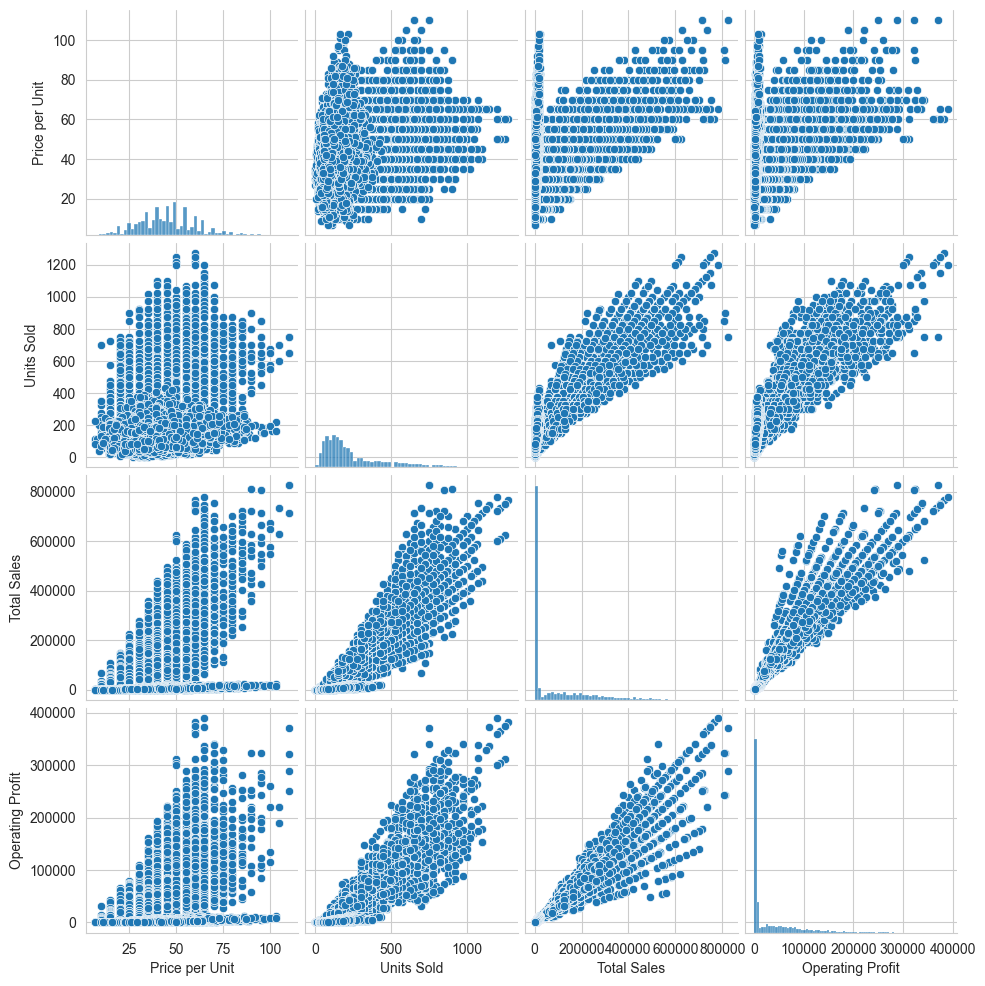

In [15]:
num_cols = ["Price per Unit", "Units Sold", "Total Sales", "Operating Profit"]
sns.pairplot(df_adidas[num_cols])
plt.show()

**Estudio del target**

<Axes: xlabel='Operating Profit', ylabel='Count'>

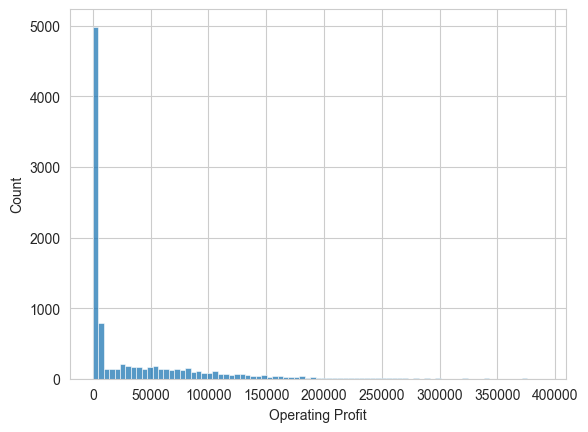

In [16]:
sns.histplot(df_adidas['Operating Profit'])

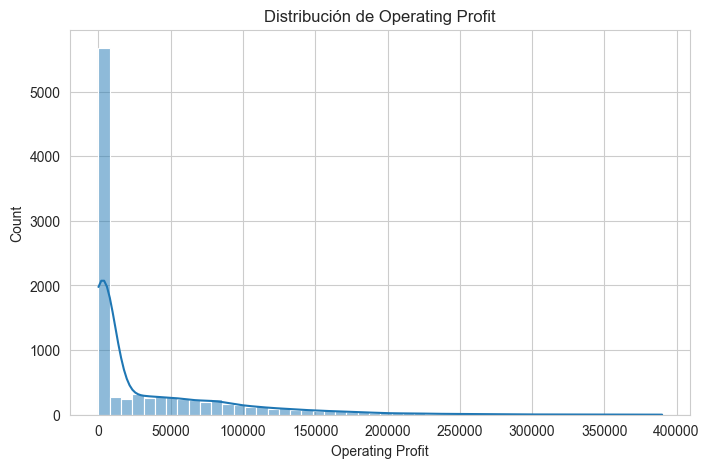

In [17]:
plt.figure(figsize=(8,5))
sns.histplot(df_adidas["Operating Profit"], bins=50, kde=True)
plt.title("Distribución de Operating Profit")
plt.show()

Boxplot

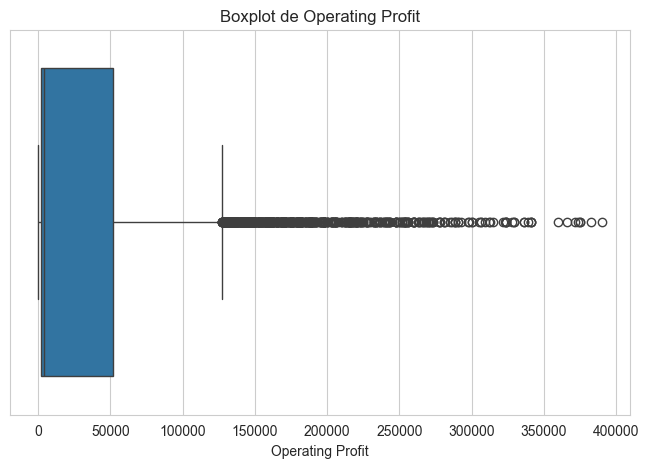

In [18]:
plt.figure(figsize=(8,5))
sns.boxplot(x=df_adidas["Operating Profit"])
plt.title("Boxplot de Operating Profit")
plt.show()

In [19]:
df_adidas["Operating Profit"].describe(percentiles=[0.01, 0.25, 0.5, 0.75, 0.99])

count      9648.000000
mean      34425.244761
std       54193.113713
min           0.000000
1%          344.862600
25%        1921.752500
50%        4371.420000
75%       52062.500000
99%      242647.500000
max      390000.000000
Name: Operating Profit, dtype: float64

**Correlaciones**

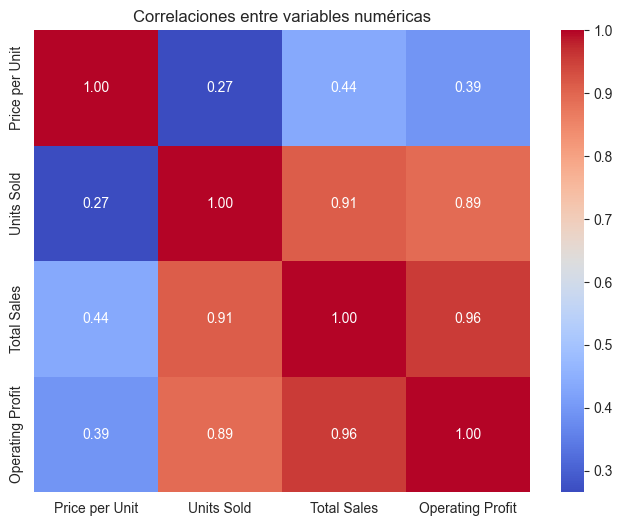

In [20]:
corr = df_adidas[num_cols].corr()
plt.figure(figsize=(8,6))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Correlaciones entre variables numéricas")
plt.show()

**Análisis univariante**

Numéricas:

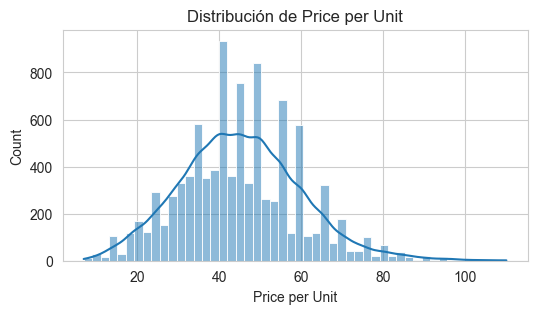

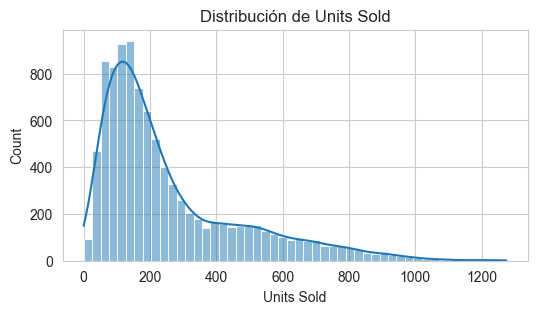

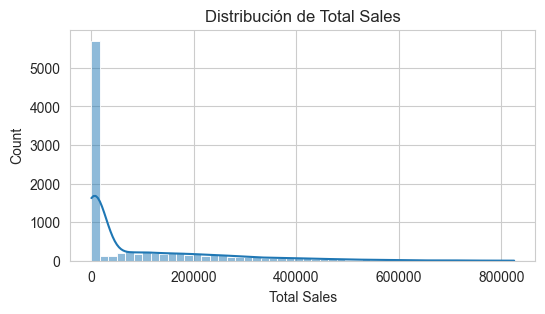

In [21]:
for col in ["Price per Unit", "Units Sold", "Total Sales"]:
    plt.figure(figsize=(6,3))
    sns.histplot(df_adidas[col], bins=50, kde=True)
    plt.title(f"Distribución de {col}")
    plt.show()

Categóricas:

In [22]:
categorical_cols = ["Region", "Product", "Sales Method"]
for col in categorical_cols:
    print(df_adidas[col].value_counts())

Region
West         2448
Northeast    2376
Midwest      1872
South        1728
Southeast    1224
Name: count, dtype: int64
Product
Men's Street Footwear        1610
Men's Athletic Footwear      1610
Women's Street Footwear      1608
Women's Apparel              1608
Women's Athletic Footwear    1606
Men's Apparel                1606
Name: count, dtype: int64
Sales Method
Online      4889
Outlet      3019
In-store    1740
Name: count, dtype: int64


array([[<Axes: title={'center': 'Retailer ID'}>,
        <Axes: title={'center': 'Invoice Date'}>,
        <Axes: title={'center': 'Price per Unit'}>],
       [<Axes: title={'center': 'Units Sold'}>,
        <Axes: title={'center': 'Total Sales'}>,
        <Axes: title={'center': 'Operating Profit'}>],
       [<Axes: title={'center': 'Operating Margin'}>, <Axes: >, <Axes: >]],
      dtype=object)

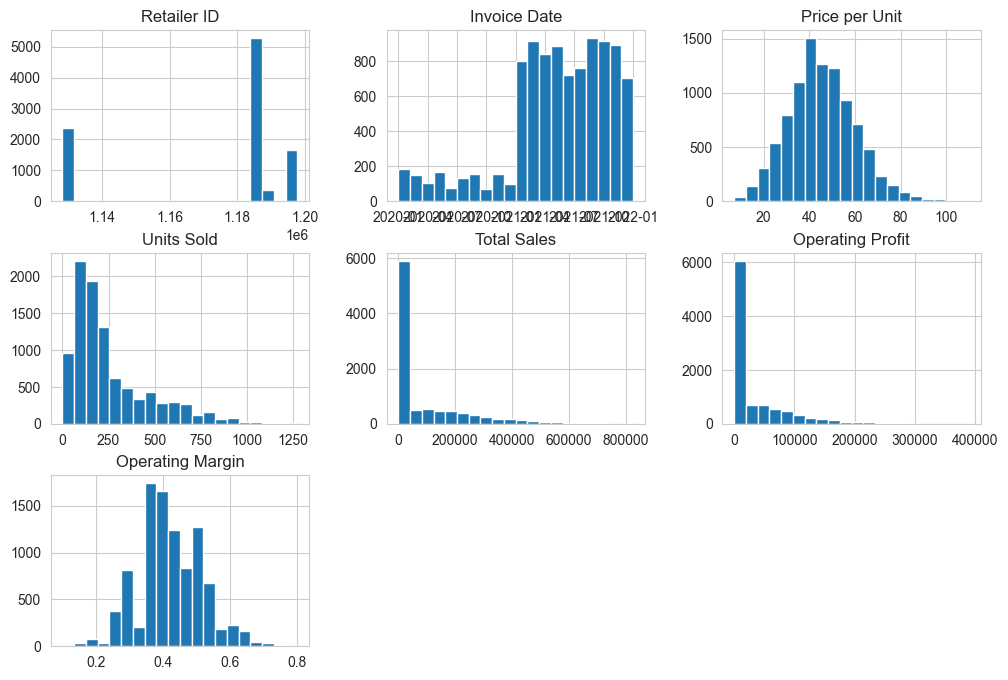

In [46]:
df_adidas.hist(figsize=(12,8), bins=20)

**Análisis bivariante**

Relación entre Operating Profit y variables numéricas

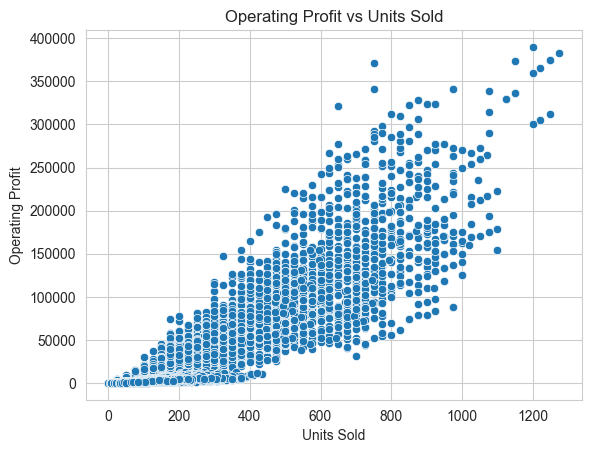

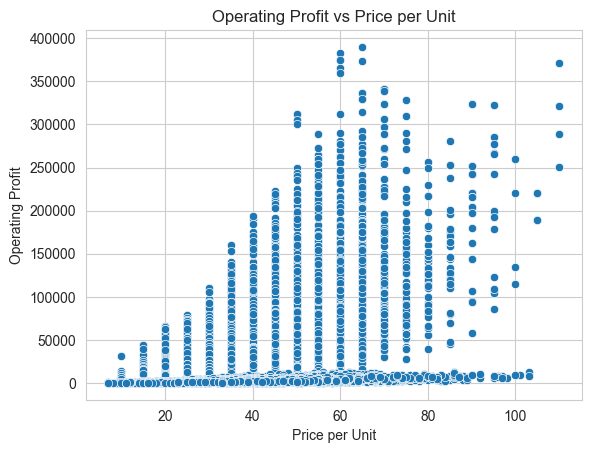

In [23]:
sns.scatterplot(x="Units Sold", y="Operating Profit", data=df_adidas)
plt.title("Operating Profit vs Units Sold")
plt.show()

sns.scatterplot(x="Price per Unit", y="Operating Profit", data=df_adidas)
plt.title("Operating Profit vs Price per Unit")
plt.show()

Relación con categóricas (boxplots):

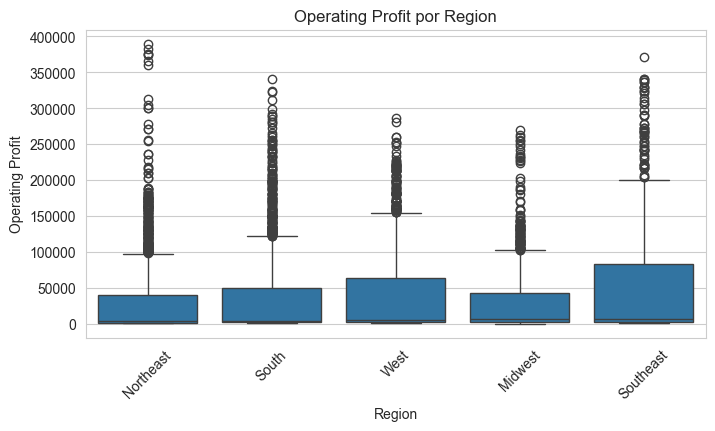

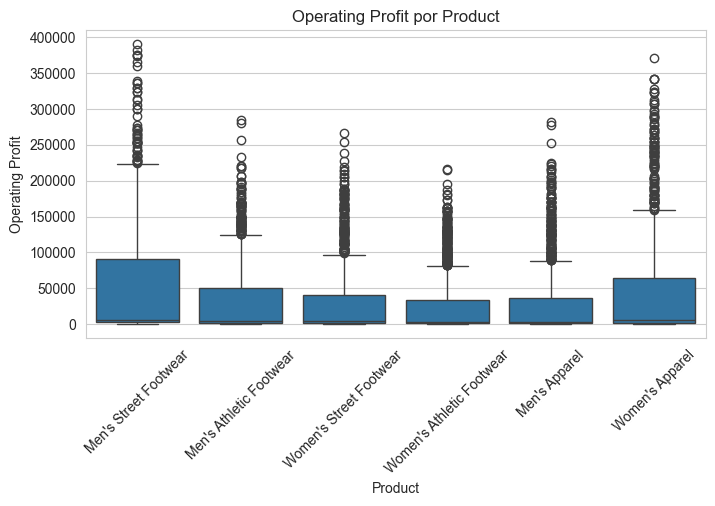

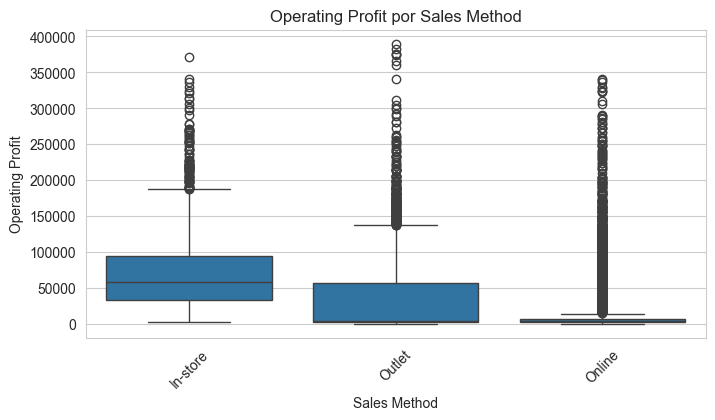

In [24]:
for col in ["Region", "Product", "Sales Method"]:
    plt.figure(figsize=(8,4))
    sns.boxplot(x=col, y="Operating Profit", data=df_adidas)
    plt.title(f"Operating Profit por {col}")
    plt.xticks(rotation=45)
    plt.show()

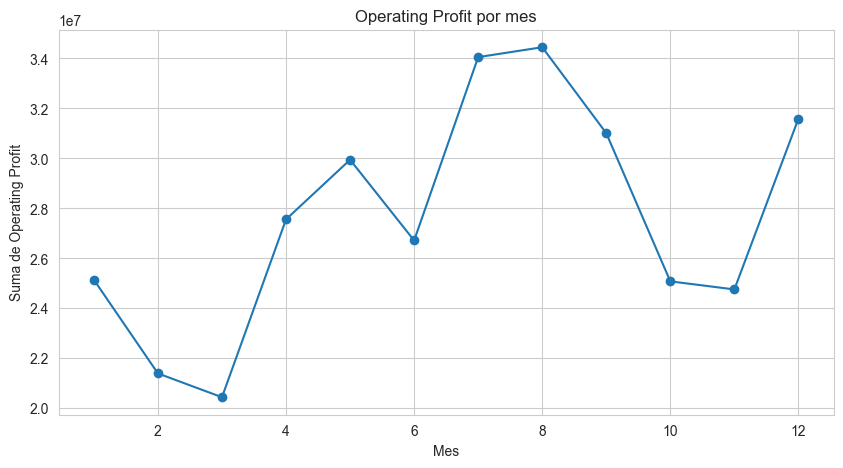

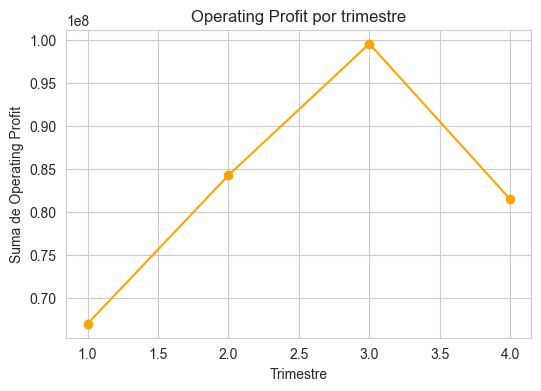

In [48]:
# Crear columnas temporales
df_adidas['month'] = df_adidas['Invoice Date'].dt.month
df_adidas['quarter'] = df_adidas['Invoice Date'].dt.quarter
df_adidas['day_of_week'] = df_adidas['Invoice Date'].dt.dayofweek

# Tendencia mensual de Operating Profit
plt.figure(figsize=(10,5))
df_adidas.groupby('month')['Operating Profit'].sum().plot(marker='o')
plt.title("Operating Profit por mes")
plt.xlabel("Mes")
plt.ylabel("Suma de Operating Profit")
plt.grid(True)
plt.show()

# Tendencia por trimestre
plt.figure(figsize=(6,4))
df_adidas.groupby('quarter')['Operating Profit'].sum().plot(marker='o', color='orange')
plt.title("Operating Profit por trimestre")
plt.xlabel("Trimestre")
plt.ylabel("Suma de Operating Profit")
plt.grid(True)
plt.show()

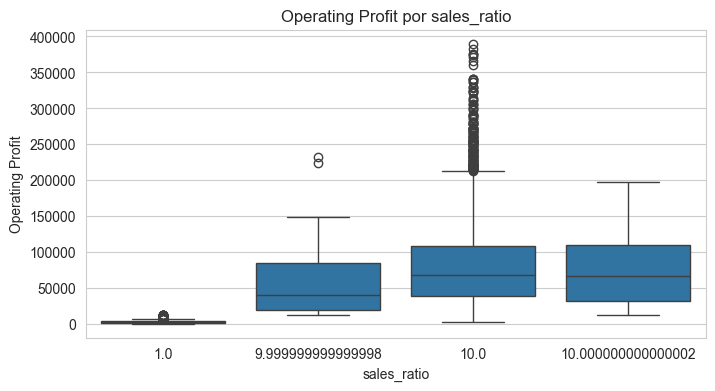

In [49]:
#distribucion del target por subgrupos:
plt.figure(figsize=(8,4))
sns.boxplot(x='sales_ratio', y='Operating Profit', data=df_adidas)
plt.title("Operating Profit por sales_ratio")
plt.show()

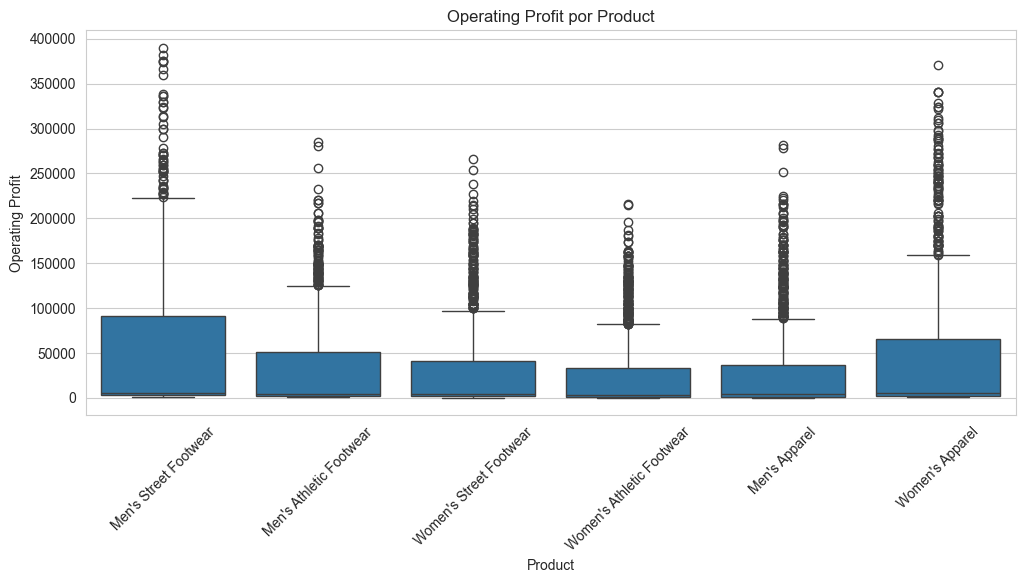

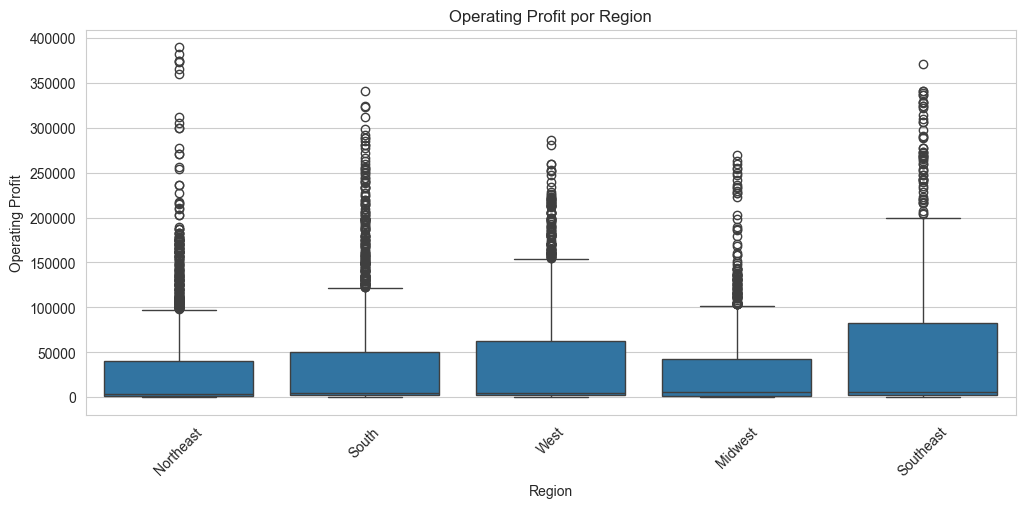

In [50]:
#distirbucion del target por producto y region
plt.figure(figsize=(12,5))
sns.boxplot(x='Product', y='Operating Profit', data=df_adidas)
plt.title("Operating Profit por Product")
plt.xticks(rotation=45)
plt.show()

plt.figure(figsize=(12,5))
sns.boxplot(x='Region', y='Operating Profit', data=df_adidas)
plt.title("Operating Profit por Region")
plt.xticks(rotation=45)
plt.show()

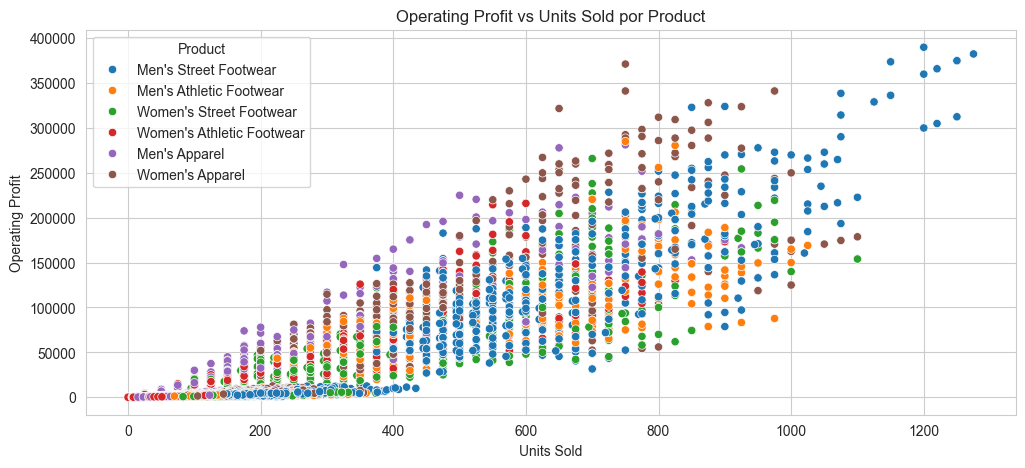

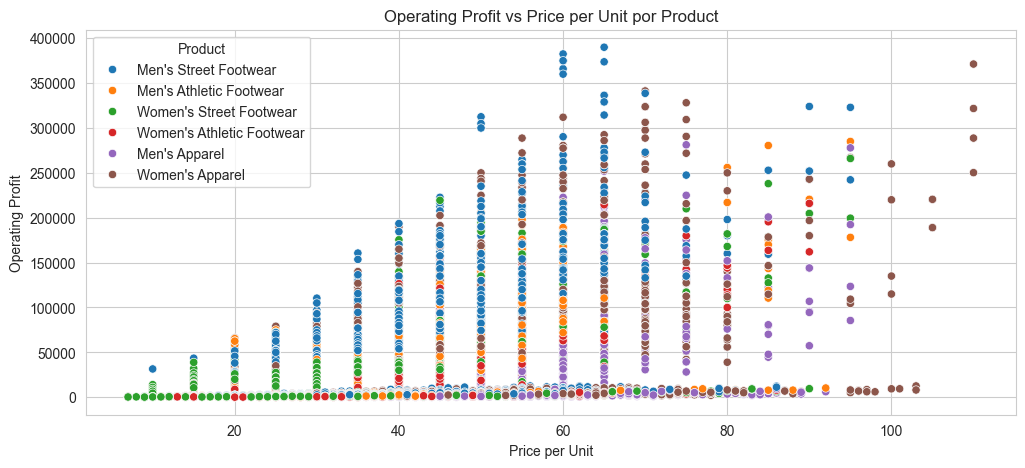

In [51]:
# Units Sold × Product
plt.figure(figsize=(12,5))
sns.scatterplot(x='Units Sold', y='Operating Profit', hue='Product', data=df_adidas)
plt.title("Operating Profit vs Units Sold por Product")
plt.show()

# Price × Product
plt.figure(figsize=(12,5))
sns.scatterplot(x='Price per Unit', y='Operating Profit', hue='Product', data=df_adidas)
plt.title("Operating Profit vs Price per Unit por Product")
plt.show()

**5. TRATAMIENTO DE VARIABLES**

In [54]:
# Revisando por aqui

> TRATAR EL PROBLEMA DE LA INCONSISTENCIA DE DATOS!

**Eliminacion de features**

In [138]:
df_adidas = df_adidas.drop(columns=["Operating Margin", "Total Sales"])

**Eliminar duplicados**

In [160]:
df_adidas = df_adidas.drop_duplicates()

**Anomalias y errores**

In [161]:
upper_limit = df_adidas["Operating Profit"].quantile(0.99)
df_adidas = df_adidas[df_adidas["Operating Profit"] <= upper_limit]

**Outliers**

In [162]:
num_cols = ["Price per Unit", "Units Sold"]
for col in num_cols:
    q1 = df_adidas[col].quantile(0.25)
    q3 = df_adidas[col].quantile(0.75)
    iqr = q3 - q1
    lower = q1 - 1.5*iqr
    upper = q3 + 1.5*iqr
    df_adidas = df_adidas[(df_adidas[col] >= lower) & (df_adidas[col] <= upper)]

**Transformaciones**

In [163]:
df_adidas["year"] = df_adidas["Invoice Date"].dt.year
df_adidas["month"] = df_adidas["Invoice Date"].dt.month
df_adidas = df_adidas.drop("Invoice Date", axis=1)

In [143]:
X.dtypes.value_counts()

int64    119
Name: count, dtype: int64

**Encodigns**

In [164]:
categorical_cols = ["Retailer", "Region", "State", "City", "Product", "Sales Method"]

df_adidas = pd.get_dummies(df_adidas, columns=categorical_cols, drop_first=True)

**Escalado**

In [165]:
scaler = StandardScaler()
num_cols = ["Price per Unit", "Units Sold", "year", "month"]
df_adidas[num_cols] = scaler.fit_transform(df_adidas[num_cols])

**6. FEATURE ENGINEERING**

In [166]:
df_adidas["Price_x_Units"] = df_adidas["Price per Unit"] * df_adidas["Units Sold"]

In [167]:
df_adidas["quarter"] = df_adidas["month"].apply(lambda x: (x-1)//3 + 1)
df_adidas["holiday_season"] = df_adidas["month"].apply(lambda x: 1 if x in [11,12] else 0)

**7. ELECCIÓN DE MÉTRICAS**

R² + RMSE

**DIVISON DE TRAIN Y TEST**

In [168]:
X = df_adidas.drop("Operating Profit", axis=1)
y = df_adidas["Operating Profit"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


**8. SELECCIÓN DE MODELO**

**BASELINE - Regresión lineal**

In [169]:
from sklearn.linear_model import LinearRegression

#Entrenamos
model = LinearRegression()
model.fit(X_train, y_train)


LinearRegression()

In [170]:
#hacemos predicciones
y_pred = model.predict(X_test)

.

In [171]:
# Evaluamos
from sklearn.metrics import r2_score, mean_squared_error


r2 = r2_score(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print("R2:", r2)
print("RMSE:", rmse)

R2: 0.9501454629540111
RMSE: 8198.279392927177


In [172]:
coef_df = pd.DataFrame({
    "feature": X_train.columns,
    "coef": model.coef_
}).sort_values(by="coef", ascending=False)

coef_df.head(10)

,feature,coef
4,Operating Margin,63002.571587
99,City_New York,4539.540684
122,Sales Method_Outlet,3500.963860
110,City_San Francisco,2611.336825
95,City_Miami,2038.985547
19,State_California,2036.745061
20,State_Colorado,1752.604118
80,City_Denver,1752.604118
97,City_Minneapolis,1721.939879
37,State_Minnesota,1721.939879


**ELIMINACIÓN DE DATA LEAKAGE**

En el dataset existen variables que contienen información directa sobre la variable objetivo (Operating Profit), lo que puede provocar leakage.

En concreto:
* Total Sales
* Operating Margin

Esto se debe a que:
* Operating Profit ≈ Total Sales × Operating Margin

Si dejamos estas variables en el modelo, este no estaría aprendiendo patrones reales, sino reconstruyendo una fórmula matemática, lo que produce métricas artificialmente altas (R² inflado).

Por tanto, eliminamos estas variables para construir un modelo más realista y generalizable.

In [173]:
X = df_adidas.drop(["Operating Profit", "Total Sales", "Operating Margin"], axis=1)
y = df_adidas["Operating Profit"]

In [174]:
# Dividimos nuevamente en train y test (ya sin data leakage)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Entrenamos el modelo
model = LinearRegression()
model.fit(X_train, y_train)

# Hacemos predicciones
y_pred = model.predict(X_test)

# Evaluamos
r2 = r2_score(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print("R²:", r2)
print("RMSE:", rmse)

# Coeficientes del modelo
coef_df = pd.DataFrame({
    "feature": X_train.columns,
    "coef": model.coef_
}).sort_values(by="coef", ascending=False)

coef_df.head(10)


R²: 0.9083327277911566
RMSE: 11116.741957437906


,feature,coef
2,Units Sold,33003.024341
121,Price_x_Units,8525.723862
60,State_West Virginia,7193.927558
91,City_Louisville,6989.394638
29,State_Kentucky,6989.394638
75,City_Chicago,5500.746627
25,State_Illinois,5500.746627
100,City_Omaha,4918.094762
39,State_Nebraska,4918.094762
1,Price per Unit,4688.332427


**Comparación con otros modelos**

In [175]:
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor

# ---- MODELOS A EVALUAR ----
models = {
    "LinearRegression": LinearRegression(),
    "Ridge": Ridge(alpha=1.0),
    "Lasso": Lasso(alpha=0.001),
    "ElasticNet": ElasticNet(alpha=0.001, l1_ratio=0.5),
    "RandomForest": RandomForestRegressor(n_estimators=100, random_state=42),
    "GradientBoosting": GradientBoostingRegressor(n_estimators=100, learning_rate=0.1, random_state=42)
}

# ---- ENTRENAMIENTO Y EVALUACION ----
results = []

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    r2 = r2_score(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    results.append({"Model": name, "R2": r2, "RMSE": rmse})

results_df = pd.DataFrame(results).sort_values(by="R2", ascending=False)
print(results_df)

              Model        R2          RMSE
4      RandomForest  0.957603   7560.265542
5  GradientBoosting  0.929828   9726.389797
0  LinearRegression  0.908333  11116.741957
2             Lasso  0.908333  11116.743535
1             Ridge  0.908292  11119.202625
3        ElasticNet  0.908199  11124.846291


RandomForest - R2: 0.9576, RMSE: 7560.27


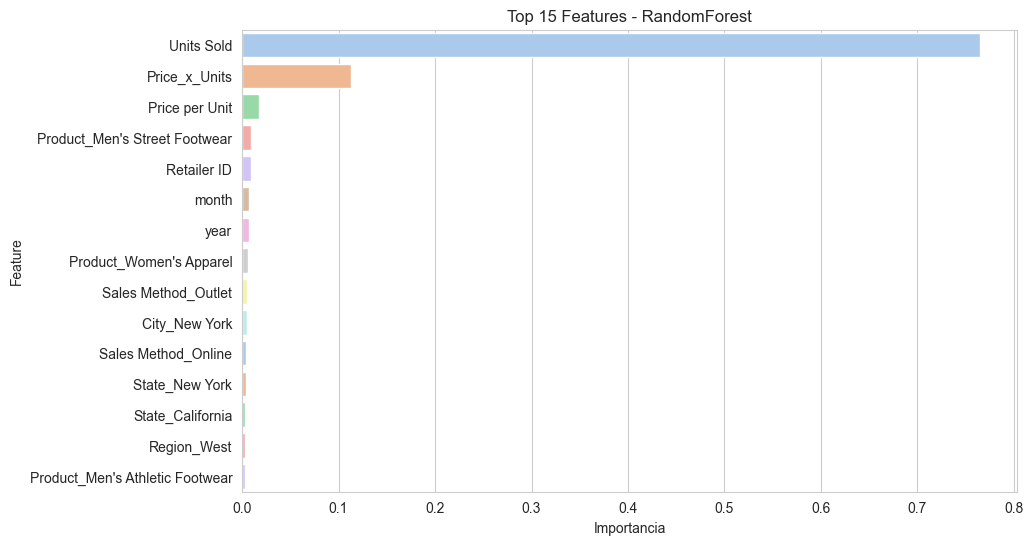

GradientBoosting - R2: 0.9298, RMSE: 9726.39


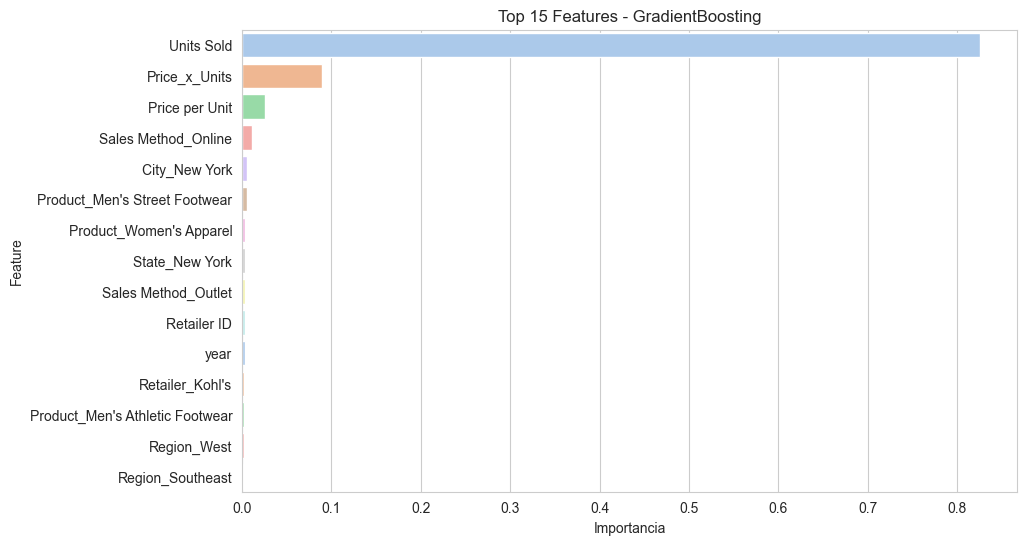

In [176]:
# ---- IMPORTANCIA DE VARIABLES PARA MODELOS DE ARBOL ----
tree_models = {
    "RandomForest": RandomForestRegressor(n_estimators=100, random_state=42),
    "GradientBoosting": GradientBoostingRegressor(n_estimators=100, learning_rate=0.1, random_state=42)
}

for name, model in tree_models.items():
    # Entrenamiento
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    
    # Evaluación
    r2 = r2_score(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    print(f"{name} - R2: {r2:.4f}, RMSE: {rmse:.2f}")
    
    # Importancia de variables
    importances = pd.DataFrame({
        "feature": X_train.columns,
        "importance": model.feature_importances_
    }).sort_values(by="importance", ascending=False).head(15)  # top 15 features
    
    # Gráfico
    plt.figure(figsize=(10,6))
    sns.barplot(x="importance", y="feature", data=importances, palette="pastel")
    plt.title(f"Top 15 Features - {name}")
    plt.xlabel("Importancia")
    plt.ylabel("Feature")
    plt.show()

Escogemos **RANDOM FOREST**

**Optimización de Hiperparámetros**

In [177]:
from sklearn.model_selection import RandomizedSearchCV
import numpy as np


rf = RandomForestRegressor(random_state=42)


param_dist = {
    "n_estimators": [50, 100, 150, 200],
    "max_depth": [None, 10, 20, 30],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4],
    "max_features": ["auto", "sqrt", "log2"]
}


random_search = RandomizedSearchCV(
    estimator=rf,
    param_distributions=param_dist,
    n_iter=50,           
    cv=5,                
    scoring="r2",        
    n_jobs=-1,         
    verbose=2,
    random_state=42
)


random_search.fit(X_train, y_train)

# Mejor combinación y mejor modelo
print("Mejores hiperparámetros:", random_search.best_params_)
best_rf = random_search.best_estimator_

Fitting 5 folds for each of 50 candidates, totalling 250 fits
Mejores hiperparámetros: {'n_estimators': 200, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_features': 'sqrt', 'max_depth': None}


                               feature  importance
2                           Units Sold    0.421907
121                      Price_x_Units    0.219057
1                       Price per Unit    0.103232
119                Sales Method_Online    0.054446
120                Sales Method_Outlet    0.020734
4                                month    0.020713
0                          Retailer ID    0.009835
116            Product_Women's Apparel    0.009374
115      Product_Men's Street Footwear    0.008313
117  Product_Women's Athletic Footwear    0.004968


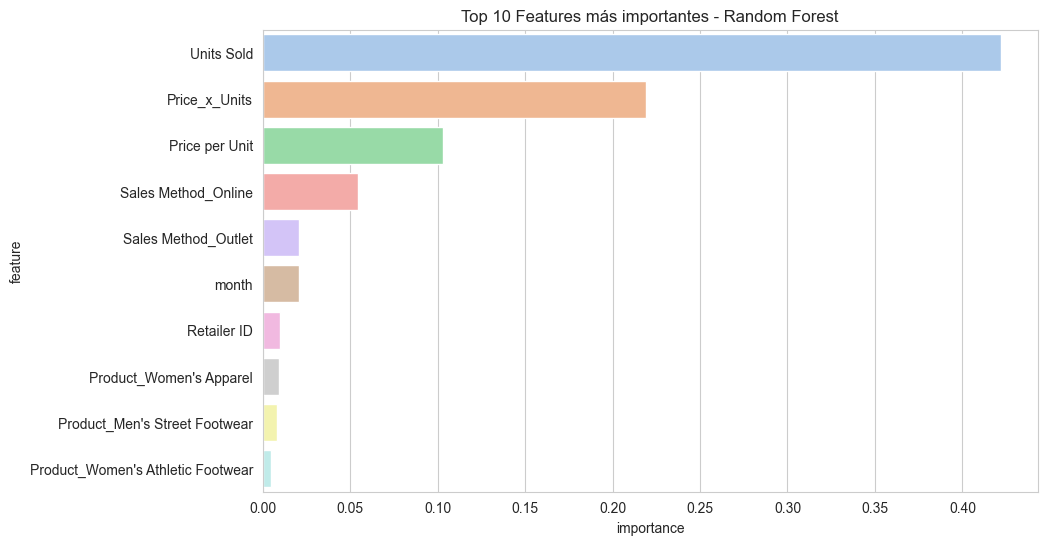

In [178]:
# Extraer importancia de features
feature_importances = pd.DataFrame({
    "feature": X_train.columns,
    "importance": best_rf.feature_importances_
}).sort_values(by="importance", ascending=False)

# Mostrar top 10
print(feature_importances.head(10))

# Gráfico
plt.figure(figsize=(10,6))
sns.barplot(x="importance", y="feature", data=feature_importances.head(10), palette="pastel")
plt.title("Top 10 Features más importantes - Random Forest")
plt.show()

In [179]:
from sklearn.model_selection import cross_val_score


# Validación cruzada 5-fold
cv_scores = cross_val_score(best_rf, X_train, y_train, cv=5, scoring="r2", n_jobs=-1)

print("R2 promedio CV:", np.mean(cv_scores))
print("R2 std CV:", np.std(cv_scores))

R2 promedio CV: 0.9492577342773864
R2 std CV: 0.00690670451100935


**Sobre test**

In [180]:
from sklearn.model_selection import cross_val_score
import numpy as np

# Validación cruzada 5-fold
cv_scores = cross_val_score(best_rf, X_train, y_train, cv=5, scoring="r2", n_jobs=-1)

print("R2 promedio CV:", np.mean(cv_scores))
print("R2 std CV:", np.std(cv_scores))

R2 promedio CV: 0.9492577342773864
R2 std CV: 0.00690670451100935


**Persistencia**

In [ ]:
import joblib

# Guardar
joblib.dump(best_rf, "best_random_forest.pkl")

# Cargar después!!!
# loaded_model = joblib.load("best_random_forest.pkl")